# Exploration

This notebook is for general use to create some probing plots and small explorations for quick codes that do not need the cluster.

## EBL Data

This is for exploring the EBL data provided by Simon Driver. Data is in a csv file in data/ebl/ebldata.csv. Columns are: wavelength, $\lambda$ (microns), $\lambda I_\lambda$,( nW $m^{-2}$ $sr^{-1}$), $\Delta\lambda I_\lambda$, and reference.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import h5py
sys.path.append("/home/spujni/simba_cosmic_background")

from src.utils import load_background_results

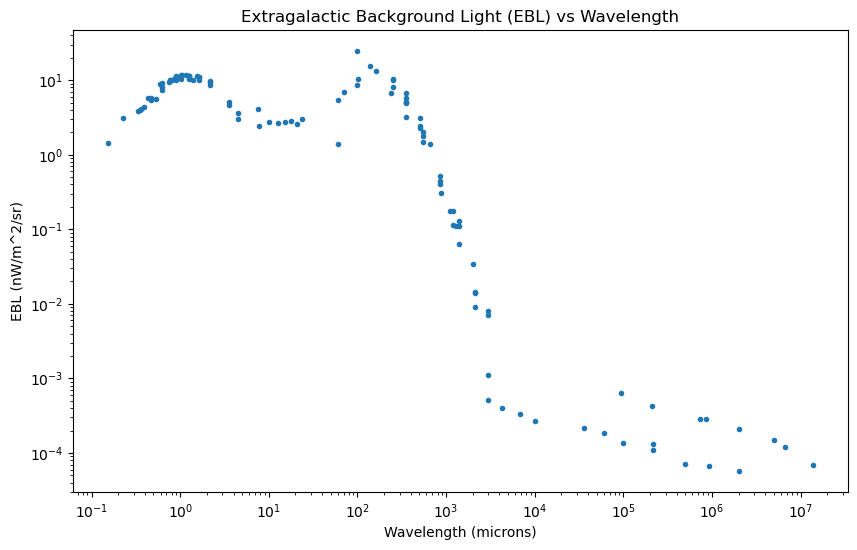

In [7]:
df = pd.read_csv(r"/home/spujni/simba_cosmic_background/data/ebl/ebldata.csv")
df = df.sort_values(by = "wave")

# ── Mask out negligible values so the log plot isn't wrecked ──
floor = 1e-6
# df["ebl"] = np.where(df["ebl"] < floor, np.nan, df["ebl"])

# df = df[~(((df["wave"] == 100)) & (df["paper"] == "casandjian2024"))]

plt.figure(figsize=(10, 6))
plt.scatter(df["wave"], df["ebl"], marker=".")
plt.xlabel("Wavelength (microns)")
plt.ylabel("EBL (nW/m^2/sr)")
plt.title("Extragalactic Background Light (EBL) vs Wavelength")
plt.xscale("log")
plt.yscale("log")
plt.show()  


Loaded results from /home/spujni/simba_cosmic_background/data/results/bg_m100n1024_a0.5_z0.0-7.0.h5
dict_keys(['lam_AA', 'I_nu', 'nuInu_nW', 'I_nu_nodust', 'nuInu_nodust_nW'])


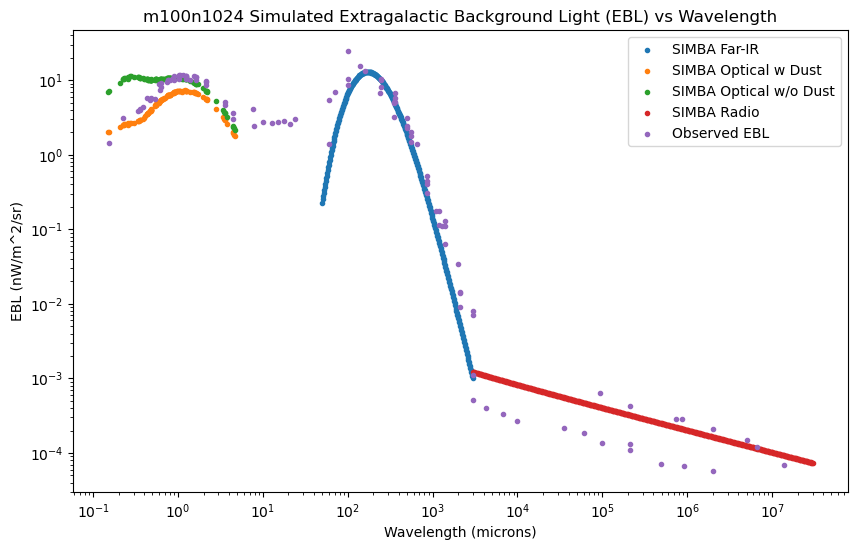

In [8]:
data = load_background_results("m100n1024", area=0.5, z_min=0.0, z_max=7.0)

print(data["optical"].keys())

# spectra
lam_fir = data["farIR"]["lam_AA"] * 1e-4  # µm
nuInu_fir = data["farIR"]["nuInu_nW"]

lam_opt = data["optical"]["lam_AA"] * 1e-4  # µm
nuInu_opt = data["optical"]["nuInu_nW"]

nuInu_opt_nodust = data["optical"]["nuInu_nodust_nW"]

lam_radio = data["radio"]["lam_um"]  # µm
nuInu_radio = data["radio"]["nuInu_nW"]

fir_lo, fir_hi = 50, 3000  # microns
fir_mask = (lam_fir >= fir_lo) & (lam_fir <= fir_hi) & np.isfinite(nuInu_fir)

plt.figure(figsize=(10, 6))
plt.scatter(lam_fir[fir_mask], nuInu_fir[fir_mask], marker=".", label="SIMBA Far-IR")
plt.scatter(lam_opt, nuInu_opt, marker=".", label="SIMBA Optical w Dust")
plt.scatter(lam_opt, nuInu_opt_nodust, marker=".", label="SIMBA Optical w/o Dust")
plt.scatter(lam_radio, nuInu_radio, marker=".", label="SIMBA Radio")
plt.scatter(df["wave"], df["ebl"], marker=".", label="Observed EBL")
#plt.errorbar(df["wave"], df["ebl"], yerr=df["debl"], fmt="none", ecolor="gray", alpha=0.5, label="EBL Uncertainty")
plt.xlabel("Wavelength (microns)")
plt.ylabel("EBL (nW/m^2/sr)")
plt.title("m100n1024 Simulated Extragalactic Background Light (EBL) vs Wavelength")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

Running jackknife EBL on m100n1024 (box=100.0 Mpc/h)

Lightcone cached: /home/spujni/simba_cosmic_background/data/lightcones/lc_m100n1024_a0.5_z0.0-7.0.h5

Jackknife EBL: 4x4 = 16 sub-regions

=== Far-IR background ===
Far-IR jackknife: 240883 galaxies, 16 sub-regions
  Jackknife realization 1/16 ...
  Jackknife realization 2/16 ...
  Jackknife realization 3/16 ...
  Jackknife realization 4/16 ...
  Jackknife realization 5/16 ...
  Jackknife realization 6/16 ...
  Jackknife realization 7/16 ...
  Jackknife realization 8/16 ...
  Jackknife realization 9/16 ...
  Jackknife realization 10/16 ...
  Jackknife realization 11/16 ...
  Jackknife realization 12/16 ...
  Jackknife realization 13/16 ...
  Jackknife realization 14/16 ...
  Jackknife realization 15/16 ...
  Jackknife realization 16/16 ...
  Far-IR done. Peak intensity: 1.094e+01 nW/m²/sr

=== Radio background ===
Radio jackknife: 240883 galaxies, 16 sub-regions
  Jackknife realization 1/16 ...
  Jackknife realization 2/16 ...
  Jac

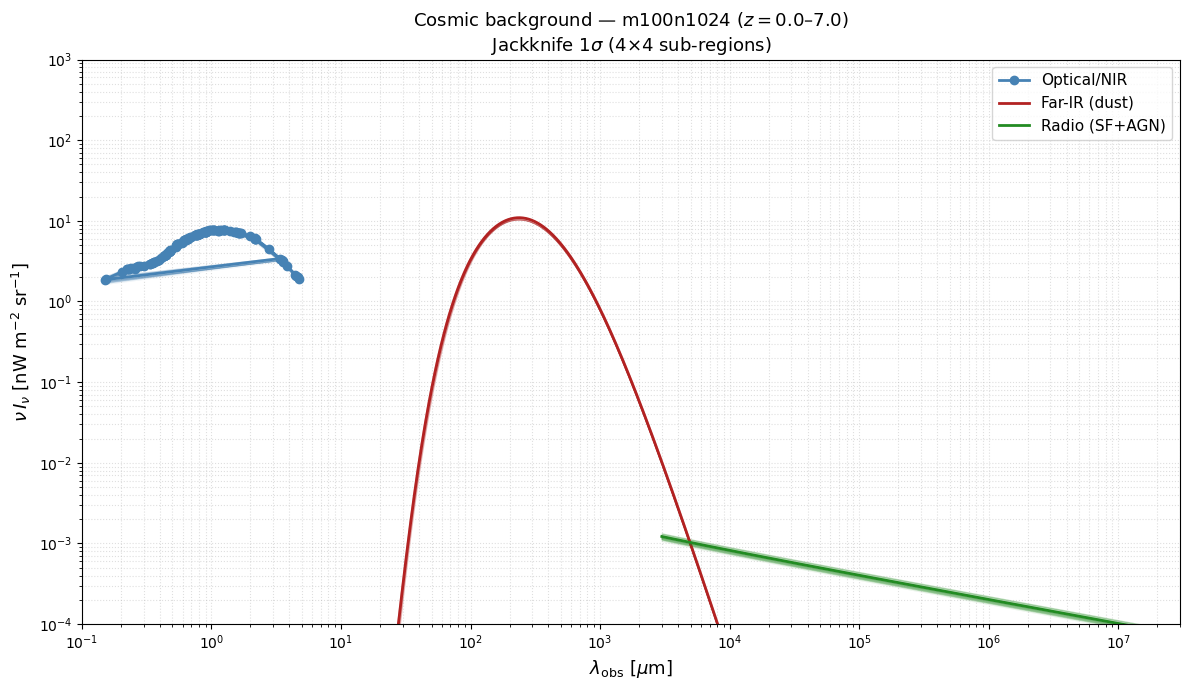

In [8]:
from scripts.jackknife_lightcone import run_jackknife_ebl, print_jackknife_summary

results = run_jackknife_ebl("m100n1024", area=0.5)
print_jackknife_summary(results)

# Access errors:
fir_err = results["farIR"]["nuInu_err_nW"]  # 1-sigma errors